# 实验2 线性分类器

**任务：**  
**1. 把上面的程序补充完整，画出训练过程中训练精度**  
**2. 分类器前再增加2层（三层神经网络）使用Relu激活函数，画出训练精度，分析结果**  
**3. 上面使用梯度下降法训练线性分类器，效果似乎并不好，对其进行优化。**  

**思路：**  
**1. 对于任务1，直接补全相关代码，创建变量accuracies、losses用于存储中间值，最后使用matplotlib.pyplot绘制准确率和损失随迭代次数的变化图像即可**  
**2. 特别的，对于任务2和任务3，我们将其放在一起解决（或者说我们将相关代码都放在一个二级标题下来解决），我们添加两个隐藏层，且这两个隐藏层的激活函数都使用Relu，输出层的激活函数使用Softmax，通过不断调节各种超参数、修改一系列优化方法最终获得一个表现较为理想的浅层神经网络**  

## 读取MNIST数据集，并将其划分为train/val/test数据集

### MNIST数据集读取

In [21]:
import gzip
import os
import struct
import numpy as np
import matplotlib.pyplot as plt  #用于绘图

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)
        labels=labels.astype(np.int32)  #和第一次实验课作业一样，不要忘记对labels和images强转类型！

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)
        images=images.astype(np.int32)/255.0  #这里有一个特别点值得我们的关注，就是这里使用了"/255"操作，
                                              #实际上，这就是"归一化"(Normalization)操作,特征工程中最基本的环节
                                              #详细操作请看"使用梯度下降法，训练线性分类器"这一部分

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    temp=np.random.permutation(images.shape[0])
    images=images[temp]
    labels=labels[temp]
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)
    
    val_img = images[:offset][:]
    val_lb = labels[:offset]
    
    train_img = images[offset:][:]
    train_lb = labels[offset:]
    
    return train_img, train_lb, val_img, val_lb    

### 按照 5:1:1 划分为训练集，验证集，测试集


In [22]:
[images, labels] = load_mnist('./MNIST/', kind='train')
[test_img, test_lb] = load_mnist('./MNIST/', kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)


## 用Random Search + Cross Entroy Loss来训练Linear Classifier

### 用向量化计算Cross Entroy Loss

In [23]:
def vectorized_loss_softmax(X, y, W):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - W: Indexs of linear classifier, a numpy array of shape (D, C) containing weights.
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns a tuple of:
    - Softmax loss as single float.
    """
    
    # set the value of delta, lamda
    delta = 1.0
    lamda = 1.0
    num_train = X.shape[0]
    num_class = W.shape[1]
    
    # scores: class x examples
    scores = W.T.dot(X.T)  #获取了形状为(C,N)的原始得分矩阵scores
    
    # scores_max: 1 x examples, get the max value from each column
    scores_max = np.max(scores,axis=0)  #之所以这么做是因为我们后续需要通过广播机制让每个样本的原始得分都减去这个样本的最大值
                                        #容易证明，对于柔性最大值函数(Softmax)，我们让每个zi减去z的最大的特征，
                                        #映射后得到的sigma(z)i的值不变，实际上这可以有效防止最大特征指数化后造成的数值溢出风险

    # prob: class x examples, calculate the log probability
    # use scores_max to limit the boundary of exp indexes
    prob = np.exp(scores-scores_max) / np.sum(np.exp(scores-scores_max), axis=0)  #获取了形状为(C,N)的原始概率分布矩阵prob

    # set value 1 in true label positions, 0 for false labels
    #构造真实标签 One-Hot
    #注：One-Hot即"独热编码"
    y_true = np.zeros(prob.shape)  #构造一个形状也为(C,N)的零矩阵y_true
    y_true[y, np.arange(num_train)] = 1.0  #此处用法为"花式索引"，会在相同索引下，将第一个可迭代对象中元素作为行坐标，
                                           #将第二个可迭代对象中的元素作为列坐标，然后对相应元素赋值
    
    # calculate the average data loss
    loss = -np.sum(y_true * np.log(prob))/num_train  #获取交叉熵损失loss
    
    return loss

### 定义训练函数

In [24]:
def random_search(X, y):  #使用随机搜索算法
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns:
    - Best indexs W
    """
    
    # sign the highest float value to best loss
    best_loss = float('inf')  #注意，最佳损失best_loss的初始值应该是inf

    #原文件中并没有写loss和best_accuracy，我们需要补充
    #同时为了任务1：画出训练过程的训练精度，我们需要创建若干列表，用于记录中间值
    best_accuracy=0.0
    accuracies=[]
    best_accuracies=[]
    
    # randomly choose different indexs W to calculate the loss
    for num in range(100):
        # W: dimension x class
        W = np.random.randn(X.shape[1], 10) * 0.0001  #W的形状为(D,C)，乘上一个小数0.0001可以防止梯度爆炸
        num_train = X.shape[0]
        num_class = W.shape[1]
        
        loss = vectorized_loss_softmax(X, y, W)
            
        # scores: class x examples
        scores =  W.T.dot(X.T)  #scores的形状为(C,N)
        
        # get the predicted labels
        # y_pred: examples
        y_pred = np.argmax(scores,axis=0)  #此处np.argmax()可以获取每个样本的原始得分最大值在哪一行，行坐标恰好对应了其预测类别
        
        # calculate the accuracy
        accuracy =np.mean(y_pred==y)*100  #如果最后打印accuracy时没有乘100，则需要在这里乘100
        accuracies.append(accuracy)

        #获取交叉熵损失，原文件没有写，我们需要补充
        loss=vectorized_loss_softmax(X, y, W)

        """
        关于记录中间值，有一个值得一提的发现，就是如果我们按照原文件中写法，以loss<best_loss为根据来更新best_accuracy，
        可能会造成best_accuracy没有呈现出非单调递减的情况，这是因为损失和准确率并不是严格的正相关关系，
        当loss小于best_loss时，accuracy可能反而小于best_accuracy,
        我的个人理解-->损失追求的是预测结果和真实结果在分布上的一致性，而准确率追求的是预测结果和真实结果在标签上的一致性
        (此处我们还是以原文件写法为准)
        """
        # update the best loss
        if loss < best_loss:
            best_loss = loss
            best_W = W
            best_acc = accuracy
            best_accuracies.append(accuracy)
        else:
            best_accuracies.append(best_accuracies[-1])
        
        # print the result for every iteration
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%  Best Loss: %.3f  Best Acc: %.3f%%" % (num+1, loss, accuracy, best_loss, best_acc))
    
    # print the final result
    print("\nBest Loss: %.3f  Best Acc: %.3f%%" % (best_loss, best_acc))

    plt.figure()
    plt.plot(np.arange(100),accuracies,color='blue',label='accuracy')
    plt.plot(np.arange(100),best_accuracies,color='red',label='best_accuracy')
    
    plt.xlabel('Iteration Times')
    plt.ylabel('Corresponding Value')
    plt.legend()
    plt.show()
    
    return best_W  #返回最佳参数best_W

### 在训练集上进行训练

Epoch: 1  Loss: 2.302  Acc: 10.518%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 2  Loss: 2.303  Acc: 10.682%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 3  Loss: 2.303  Acc: 11.146%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 4  Loss: 2.303  Acc: 8.868%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 5  Loss: 2.303  Acc: 14.638%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 6  Loss: 2.303  Acc: 10.460%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 7  Loss: 2.302  Acc: 16.330%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 8  Loss: 2.303  Acc: 10.294%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 9  Loss: 2.303  Acc: 7.688%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 10  Loss: 2.303  Acc: 9.336%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 11  Loss: 2.303  Acc: 10.940%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 12  Loss: 2.302  Acc: 11.644%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 13  Loss: 2.303  Acc: 11.608%  Best Loss: 2.302  Best Acc: 10.518%
Epoch: 14  Loss: 2.303  Acc: 7.000%  Best Loss: 2.

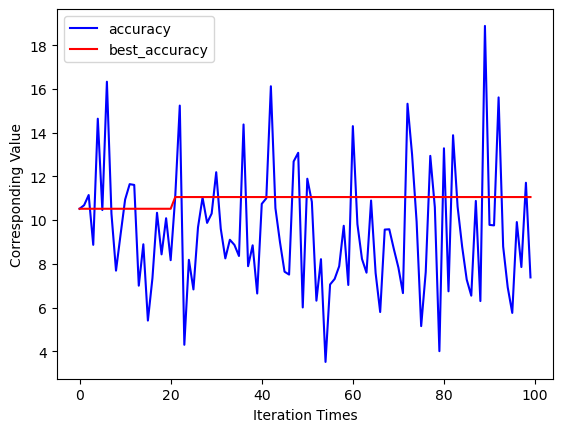

In [26]:
# train the linear classifier with random search strategy

best_W = random_search(train_img, train_lb)  #用训练集数据训练后，获取best_W

### 在验证集上测试分类的效果

In [27]:
# test the classification accuracy on validation dataset

# scores: class x examples
scores =  best_W.T.dot(val_img.T)  #形状为(C,N)

# get the predicted labels
# y_pred: examples
y_pred = np.argmax(scores,axis=0)

# calculate the accuracy
accuracy =np.mean(y_pred==val_lb)*100

# print the accuracy
print("Random Search在验证集上的分类精度为: %.3f%%" % accuracy)

Random Search在验证集上的分类精度为: 11.220%


## 使用梯度下降法，训练线性分类器

### 定义训练函数
手动计算梯度  

使用梯度下降法更新参数

线性分类器没有激活函数

损失函数使用L2

In [28]:
import numpy as np

class LinearClassifier:
    def __init__(self, input_dim, num_classes):
        
        self.W = np.random.randn(input_dim, num_classes) * 0.001  #W形状为(D,C)，input_dim指的是输入样本的特征数，num_classes指的是分类目标的样本数
        self.b = np.zeros((1, num_classes))  #b的形状是(1,C)，且所有的偏置都初始化为0

    def forward(self, X):  #X的形状为(N,D)
        # 线性映射
        return np.dot(X, self.W) + self.b  #最终形状为(N,C),此处由于让(N,C)的ndarray和(1,C)的ndarray相加，还触发了广播机制

    def compute_loss(self, y_pred, y_true):
        """使用 L2 Loss (均方误差，Mean Squared Error,简称MSE)"""
        
        # 将标签转为 One-hot 编码以计算 L2
        num_classes = y_pred.shape[1]  #y_pred的形状是(N,C)
        y_onehot = np.eye(num_classes)[y_true]
        
        loss = 0.5 * np.mean(np.sum((y_pred - y_onehot)**2, axis=1))  #我们设计MSE时往往会在前面乘上一个0.5，因为方向传播的时候
                                                                      #会因为平方求导而出现一个2，这时候0.5*2=1恰好就抵消了
        return loss, y_onehot

    def train_step(self, X, y_true, learning_rate):  #y_true的形状为(N,)
        num_samples = X.shape[0]
        
        # 1. 前向传播
        y_pred = self.forward(X)  #y_pred初始形状为(N,C)
    
        
        # 2. 计算损失和 One-hot 标签
        loss, y_onehot = self.compute_loss(y_pred, y_true)
        
        # 3. 反向传播 (手动计算梯度)
        # dL/dy_pred = (y_pred - y_onehot) / n
        grad_y = (y_pred - y_onehot) / num_samples  #这里的grad_y准确来说是前向传播损失loss对于y_pred的偏导数
                                                    #loss是一个标量，y_pred是一个形状为(N,C)的矩阵，那么loss对y_pred的偏导也应该是一个
                                                    #形状为(N,C)的矩阵
        
        grad_W = np.dot(X.T, grad_y)  #同样的，grad_W的结果也是一个和W形状相同的矩阵，因此我们要时刻检查矩阵乘法顺序是否合理
        grad_b = np.sum(grad_y, axis=0, keepdims=True)  #同理，grad_b的形状应该和b一样，是(1,C),因此我们需要加上keepdims=True (keepdims即"保持维度")
                                                        #而keepdims默认值为False，如果不改写成True的话最终grad_b的形状就是(C,)
        
        # 4. 参数更新 (梯度下降)
        self.W -= learning_rate * grad_W
        self.b -= learning_rate * grad_b
        
        return loss

    def predict(self, X):
        scores = self.forward(X)
        return np.argmax(scores, axis=1)

def evaluate(model, X, y):
    predictions = model.predict(X)
    accuracy = np.mean(predictions == y)
    return accuracy


### 在验证集上观察模型训练情况

开始训练...
Epoch [5/200], Loss: 0.4167, Val Acc: 69.1500%
Epoch [10/200], Loss: 0.3802, Val Acc: 72.8700%
Epoch [15/200], Loss: 0.3535, Val Acc: 74.1700%
Epoch [20/200], Loss: 0.3331, Val Acc: 75.1200%
Epoch [25/200], Loss: 0.3173, Val Acc: 75.7100%
Epoch [30/200], Loss: 0.3048, Val Acc: 76.3100%
Epoch [35/200], Loss: 0.2948, Val Acc: 76.8700%
Epoch [40/200], Loss: 0.2866, Val Acc: 77.1300%
Epoch [45/200], Loss: 0.2798, Val Acc: 77.5700%
Epoch [50/200], Loss: 0.2740, Val Acc: 77.9200%
Epoch [55/200], Loss: 0.2692, Val Acc: 78.1700%
Epoch [60/200], Loss: 0.2650, Val Acc: 78.4800%
Epoch [65/200], Loss: 0.2613, Val Acc: 78.6800%
Epoch [70/200], Loss: 0.2580, Val Acc: 78.9900%
Epoch [75/200], Loss: 0.2552, Val Acc: 79.3200%
Epoch [80/200], Loss: 0.2526, Val Acc: 79.5800%
Epoch [85/200], Loss: 0.2503, Val Acc: 79.8100%
Epoch [90/200], Loss: 0.2482, Val Acc: 80.0300%
Epoch [95/200], Loss: 0.2463, Val Acc: 80.1900%
Epoch [100/200], Loss: 0.2445, Val Acc: 80.3300%
Epoch [105/200], Loss: 0.2429, V

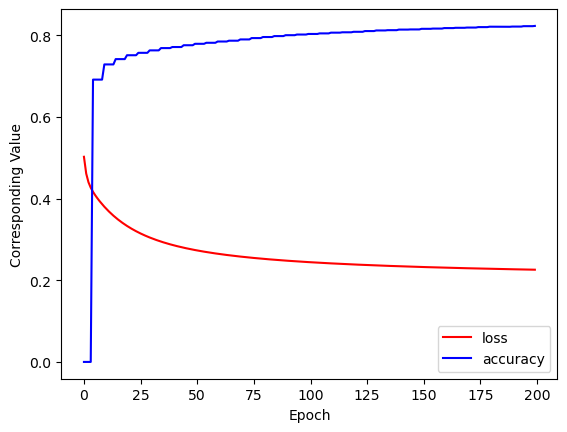

In [29]:
input_size = 784
num_classes = 10
lr = 0.01  #lr即learning rate,学习率
epochs = 200
val_acc=0

losses=[]
accuracies=[]

model = LinearClassifier(input_size, num_classes)

print("开始训练...")
for epoch in range(epochs):
    
    loss = model.train_step(train_img, train_lb, lr)
    losses.append(loss)
    
    if (epoch + 1) % 5 == 0:
        val_acc = evaluate(model, val_img, val_lb)  #原文件是不是写错了？val_acc不应该对应val_image和val_lb吗？
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}, Val Acc: {val_acc*100:.4f}%")

    accuracies.append(val_acc)    

print("训练完成！损失和准确率随更新次数的变化如图所示")

plt.figure()
plt.plot(np.arange(epochs),losses,color='red',label='loss')
plt.plot(np.arange(epochs),accuracies,color='blue',label='accuracy')
plt.xlabel('Epoch')
plt.ylabel('Corresponding Value')
plt.legend()
plt.show()

**我们成功解决了原文件中模型存在梯度爆炸的问题，一开始损失是很大的数字，后来甚至变成inf和nan了**  
**但是这个单神经元神经网络的准确率最终只有80+%，显然模型过于简单，存在欠拟合问题，这就迫使我们改用更加复杂的模型来解决问题**  
**在正式进入下一部分之前，我们要讲一下为什么原文件中模型出现梯度爆炸的原因**
 
现在我们考虑一个样本：$$x=(x_1,x_2,x_3,...,x_D)$$
以及一个权重矩阵：$$W=(W_1,W_2,W_3,...,W_K)$$
其中：$$W_i=(w_1i,w_2i,w_3i,...,w_Di)^{T} \quad i \in [1,2,3,...,K]$$
也就是说这个样本对于第$i$个神经元来说，得分情况为：$$z_i=x·W_i+b_i=\sum_{d=1}^D x_d·w_di+b_i$$
我们假定所有$x_i \quad i \in [1,2,3,...,K]$均在相同分布下，且所有$w_di \quad d \in [1,2,3,...,D] \quad i \in [1,2,3,...,K]$均在相同分布下，且$x_i和w_di$相互独立，且$Var(b_i)=0$（毕竟$b_i$是一个常数），那么我们就可以进一步得出$z_i$的方差：
$$Var(z_i)=Var(\sum_{d=1}^D x_d·w_di+b_i)$$
$$=Var(\sum_{d=1}^D x_d·w_di)+Var(b_i)$$
$$=Var(\sum_{d=1}^D x_d·w_di)$$
$$=\sum_{d=1}^D Var(x_d·w_di)$$
$$=D·Var(x·W_i)$$
$$=D·\{E([x·W_i]^2)-[E(x·W_i)]^2\}$$
$$=D·\{E(x^2)·E(W_i^2)-[E(x)]^2·[E(W_i)]^2\}$$
$$=D·\{\{Var(x)+[E(x)]^2\}·\{Var(W_i)+[E(W_i)]^2\}-[E(x)]^2·[E(W_i)]^2\}$$
$$=D·\{Var(x)·Var(W_i)+Var(x)·[E(W_i)]^2+Var(W_i)·[E(x)]^2\}$$
因为$W$是根据np.random.randn(D,K)来求出来的（randn表示的是标准正态分布，均值为0，方差&标准差为1），也就是说$E(W_i)=0$，同时我们假定$E(x)=0$，那么就有：
$$z_i=D·Var(x)·Var(W_i)=D·Var(x)·Var(W_i)=D·Var(x)·Var(W)$$
简单的理解就是随着前向传播，$z_i$的方差会越来越大，因为每一层更新我们都乘以了一个维度数D，而且在本任务中D是784，是个不小的数字，又假如我们不对Var(x)加以约束,就会导致$z_i$的方差非常大，即便我们只有一层神经网络  

那么方差大意味着什么呢？意味着随机变量$z_i$的取值分布极度分散，这意味着一旦$z_i$取了一个极端值，那么在反向传播求梯度的时候就会使得上游梯度乘以当前偏导数是一个极大的值，然后就会引发梯度爆炸，参数被大幅度更新后，下一轮正向传播的损失会更大，而之后的反向传播求梯度又会遇到更加极端的值，如此反复恶化，最终导致模型彻底失控了  

在维度D不能改变的情况下，我们就要想办法让原始样本的方差变小，或者让初始化参数的方差变小，前者我们可以采取归一化等特征工程方法，后者我们可以采取Xaiver初始化、He初始化等方法

这里模型因为梯度爆炸而导致损失越来越大的现象和学习率选择不当有些类似：  
我们考虑这样一个损失函数$J(x)=x^2$（这里的$x$是一个标量，不是向量），学习率为$\eta$，那么GD的迭代公式为:
$$x←x-\nabla J(x)=x-2\eta x=(1-2\eta)x$$
然而当$x$的初始值取$x_0\neq 0$，且当$\eta > 1$时，此时$1-2\eta<-1$，那么必然有$lim_{k \to +\infty}x_k=\pm \infty$，其中$x_k$是$x$迭代$k$次后的结果  
在这期间$J(x)$不减反增，过程类似梯度爆炸时损失loss不减反增

### 在测试集上观察模型训练情况

In [30]:
test_acc=evaluate(model,test_img,test_lb)
print(f'Test Acc: {test_acc*100:.4f}%')

Test Acc: 83.7100%


## 使用三层神经网络+MBGD算法来实现线性分类器

我们前面使用的实际上是一个单神经元神经网络，一个神经元的学习能力有限，很难以学习到训练集样本的所有特征。  
迭代200轮后，我们发现验证集的准确率约84%，也就是说模型存在欠拟合问题，这是模型自身固有性质导致的（模型自身复杂度低于问题复杂度）。  
随着模型复杂度的增进，**单神经元神经网络**可以变为**浅层神经网络**，进而变成**深层神经网络**，但是多少层才算深？多少层才算浅？并没有一个定论 。  
实际上，神经网络的层数以及每层上的神经元个数都是**超参数**，需要我们后期自己去调整。  
并且也并非是模型的复杂度越高越好，或是越低越好，对于一个理想的模型，其复杂度应该和问题的复杂度相当，既不存在过拟合问题，也不存在欠拟合问题。  
只有拥有**泛化能力**的模型才是一个理想的模型。

下面我们来试着搭建一个三层的神经网络。  
值得一提的是，我们一般不把输入层计入到神经网络的层数里，我们认为神经网络的层要么是隐藏层，要么是输出层。  
也就是说一个三层的神经网络有一个输入层，两层隐藏层和一层输出层。  

### 神经网络层类的定义

In [31]:
class ThreeLayerNN():
    def __init__(self,input_size,input_dimension,hidden1_num,hidden2_num,class_num,learning_rate):
        self.input_size=input_size
        self.input_dimension=input_dimension
        self.hidden1_num=hidden1_num
        self.hidden2_num=hidden2_num
        self.class_num=class_num
        self.learning_rate=learning_rate
        """
        特别的，为避免出现梯度消失问题，我们再初始化参数时使用了He规则化，该理论由何凯明等人提出，常用于使用Relu和Prelu激活函数的神经网络优化任务中
        该优化旨在使正向传播时，状态值的方差保持不变；反向传播时，关于激活值的梯度的方差保持不变。
        """
        #隐藏层1的相关参数
        self.W1 = np.random.randn(input_dimension, hidden1_num) * np.sqrt(2 / input_dimension)  #这里我们使用了He规则化
        self.b1=np.zeros(hidden1_num)
        #隐藏层2的相关参数
        self.W2 = np.random.randn(hidden1_num, hidden2_num) * np.sqrt(2 / hidden1_num)  #同理
        self.b2=np.zeros(hidden2_num)
        #输出层的相关参数
        self.W3 = np.random.randn(hidden2_num, class_num) * np.sqrt(2 / hidden2_num)  #同理
        self.b3=np.zeros(class_num)

    def relu(self,X):  #这里我们认为X的shape是(N,D)，N是样本数，D是input_dimension/hidden1_num,hidden2_num
        return np.maximum(X,0)

    def softmax(self,X):  #同理，我们还是认为X的形状是(N,D),但是这时候D只能取num_class
        exp_X=np.exp(X-np.max(X,axis=1,keepdims=True))
        probs=exp_X/np.sum(exp_X,axis=1,keepdims=True)

        return probs

    def relu_derivative(self,X):
        return np.where(X>0,1,0)  #找到X中大于0的指的布尔索引，让这个索引对应的元素变为1，否则变为0

    def forward_propagation(self,X):  #此处X是原始的输入样本
        self.z1=np.dot(X,self.W1)+self.b1
        self.a1=self.relu(self.z1)

        self.z2=np.dot(self.a1,self.W2)+self.b2
        self.a2=self.relu(self.z2)

        self.z3=np.dot(self.a2,self.W3)+self.b3
        self.a3=self.softmax(self.z3)
        
        return self.a3

    def get_loss(self, X, y_true):
        a3 = self.forward_propagation(X)
        y_onehot = np.eye(a3.shape[1])[y_true]
        # 交叉熵损失（加 1e-8 防止 log(0)）
        loss = -np.mean(np.sum(y_onehot * np.log(a3 + 1e-8), axis=1))
        return loss, a3, y_onehot

    def back_propagation(self,X,y_true):
        loss, a3, y_onehot = self.get_loss(X, y_true)
        # 交叉熵+Softmax 梯度简化：z3_derivative = (a3 - y_onehot)/N
        z3_derivative = (a3 - y_onehot) / X.shape[0]
        W3_derivative=np.dot(self.a2.T,z3_derivative)
        b3_derivative=np.sum(z3_derivative,axis=0)
        
        a2_derivative=np.dot(z3_derivative,self.W3.T)
        z2_derivative=a2_derivative*self.relu_derivative(self.z2)
        W2_derivative=np.dot(self.a1.T,z2_derivative)
        b2_derivative=np.sum(z2_derivative,axis=0)

        a1_derivative=np.dot(z2_derivative,self.W2.T)
        z1_derivative=a1_derivative*self.relu_derivative(self.z1)
        W1_derivative=np.dot(X.T,z1_derivative)
        b1_derivative=np.sum(z1_derivative,axis=0)

        return {
            'W3_derivative':W3_derivative,
            'b3_derivative':b3_derivative,
            'W2_derivative':W2_derivative,
            'b2_derivative':b2_derivative,
            'W1_derivative':W1_derivative,
            'b1_derivative':b1_derivative,
        },loss

    def update_parameters(self,w1_derivative,b1_derivative,w2_derivative,b2_derivative,w3_derivative,b3_derivative):
        self.w1-=self.learning_rate*w1_derivative
        self.b1-=self.learning_rate*b1_derivative
        self.w2-=self.learning_rate*w2_derivative
        self.b2-=self.learning_rate*b2_derivative
        self.w3-=self.learning_rate*w3_derivative
        self.b3-=self.learning_rate*b3_derivative

    def predict(self,X):
        a3=self.forward_propagation(X)
        y_pred=np.argmax(a3,axis=1)
        return y_pred

    def get_accuracy(self,X,y_true):
        y_pred=self.predict(X)
        return np.mean(y_pred==y_true)


### 训练模型并记录损失和准确率变化

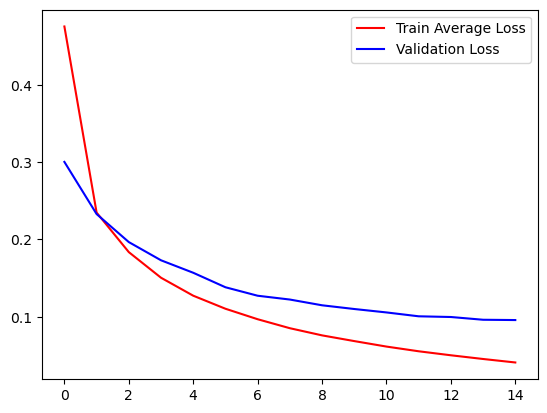

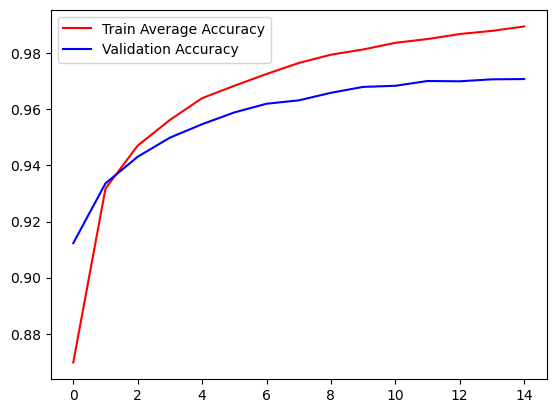

In [32]:
#设置初始化参数
input_size=train_img.shape[0]
input_dimension=train_img.shape[1]
hidden1_num=392
hidden2_num=196
class_num=10
learning_rate=0.05

epochs=15
batch_size=100
batchs=train_img.shape[0]//batch_size

train_losses=[]
train_accuracies=[]
val_losses=[]
val_accuracies=[]

model=ThreeLayerNN(input_size,input_dimension,hidden1_num,hidden2_num,class_num,learning_rate)
for epoch in range(epochs):
    temp=np.random.permutation(train_img.shape[0])
    train_img=train_img[temp]
    train_lb=train_lb[temp]
    
    loss=0
    accuracy=0
    st=0  #每次划分的起始下标
    ed=0  #每次划分的终止下标
    for batch in range(batchs):
        st=batch*batch_size
        ed=st+batch_size
        train_X=train_img[st:ed]
        train_y=train_lb[st:ed]

        current_accuracy=model.get_accuracy(train_X,train_y)
        dict,current_loss=model.back_propagation(train_X,train_y)
        model.W1-=dict['W1_derivative']*model.learning_rate
        model.b1-=dict['b1_derivative']*model.learning_rate
        model.W2-=dict['W2_derivative']*model.learning_rate
        model.b2-=dict['b2_derivative']*model.learning_rate
        model.W3-=dict['W3_derivative']*model.learning_rate
        model.b3-=dict['b3_derivative']*model.learning_rate

        loss+=current_loss
        accuracy+=current_accuracy

    loss/=batchs  #因为是通过若干个mini-batch累加得来的，所以记得取均值
    accuracy/=batchs  #同理
    train_losses.append(loss)
    train_accuracies.append(accuracy)

    current_loss,a,b=model.get_loss(val_img,val_lb)
    current_accuracy=model.get_accuracy(val_img,val_lb)
    val_losses.append(current_loss)
    val_accuracies.append(current_accuracy)

#训练集和验证集上的损失变化图像
plt.figure()
plt.plot(np.arange(epochs),train_losses,color='red',label='Train Average Loss')
plt.plot(np.arange(epochs),val_losses,color='blue',label='Validation Loss')
plt.legend()
plt.show()

#训练集和验证集上的准确率变化图像
plt.figure()
plt.plot(np.arange(epochs),train_accuracies,color='red',label='Train Average Accuracy')
plt.plot(np.arange(epochs),val_accuracies,color='blue',label='Validation Accuracy')
plt.legend()
plt.show()
        


**1. 关于损失，我们可以看到最终训练集损失约为0.05，处于完美收敛的范围内；验证集则约为0.1，处于完美的边缘，总的来说效果不错**  
**2. 关于准确率，我们可以看到最终训练集准确率约为99%，还有一点进步空间；验证集准确率约为96%，几乎停滞，且更新期间存在一定的轻微波动，总的来说效果不错**

实际上，我对于这个浅层神经网络的各种超参数和优化方法前前后后做了许多的调整：
1.  对于学习率，选择0.1太大，损失和准确率出现了严重的震荡；选择0.01太小，更新速度极满，经过epochs轮迭代后损失变化极小，说明模型几乎没学到什么东西
2.  对于迭代次数epochs，我一开始选择了20，但是验证集在后几轮有点过拟合了，于是我选择减少迭代次数，提前终止
3.  对于参数初始化，一开始我选择在W后乘以0.001，但是发现梯度消失的现象更严重，换用其他常数效果也一般，最终换用了He初始化
4.  对于损失函数，我发现将MSE改为使用Cross-entropy效果更好，至少对于这个多分类问题来说
5.  对于神经网络层的神经元数量来说，已知输入层有784（28 x 28）个神经元，于是我就将隐藏层1的神经元数设置为784/2=392，将隐藏层2的神经元数量设置为392/2=196，效果还可以，就不做过多调整了  
（当然除以2这个操作是我猜测的，应该有更好的数量关系 ^_^ ）

**最后我们再在测试集上观察模型的表现状况如何**

In [33]:
loss,a3,y_onehot=model.get_loss(test_img,test_lb)
accuracy=model.get_accuracy(test_img,test_lb)

print(f'The loss of model\'s prediction on Test Set : {loss:.4f}')
print(f'The accuracy of model\'s prediction on Test Set : {accuracy*100:.2f}%')

The loss of model's prediction on Test Set : 0.0752
The accuracy of model's prediction on Test Set : 97.56%


**可以看出模型在测试集上的损失较低，准确率很高**


完结撒花
/**
 * _ooOoo_
 * o8888888o
 * 88" . "88
 * (| -_- |)
 *  O\ = /O
 * ___/`---'\____
 * .   ' \\| |// `.
 * / \\||| : |||// \
 * / _||||| -:- |||||- \
 * | | \\\ - /// | |
 * | \_| ''\---/'' | |
 * \ .-\__ `-` ___/-. /
 * ___`. .' /--.--\ `. . __
 * ."" '< `.___\_<|>_/___.' >'"".
 * | | : `- \`.;`\ _ /`;.`/ - ` : | |
 * \ \ `-. \_ __\ /__ _/ .-` / /
 * ======`-.____`-.___\_____/___.-`____.-'======
 * `=---='
 *          .............................................
 *           佛曰：bug泛滥，我已瘫痪！
 */